### What is this project about?

This project explores how well **low-cost air sensors** (called *PurpleAir*) measure fine particle pollution in Hawaiʻi — and how those readings compare to official government air quality monitors (called *AQS*, or the Air Quality System).

We’re interested in a tiny pollutant called **PM₂.₅** (pronounced “PM two-point-five”).  
These are microscopic particles — smaller than 2.5 micrometers — that can enter the lungs and affect health.  

In Hawaiʻi, PM₂.₅ levels can rise during volcanic events, especially from the Kīlauea volcano.  
That makes it important to measure air quality accurately — but Hawaiʻi has very few official monitoring stations.  
Low-cost sensors like PurpleAir could help fill those gaps — *if* we can trust them.

This notebook tells the story of what happens when we compare these two types of measurements:
- The *official*, regulatory AQS monitors
- The *community-based*, low-cost PurpleAir sensors

Along the way, we’ll visualize, test, and model the data to understand whether these sensors tell the same story — and what factors might cause them to disagree.


### What data are we using?

We’ve combined several data sources into one merged dataset:
- **AQS (Air Quality System):** official government PM₂.₅ readings  
- **PurpleAir:** community-installed, low-cost air sensors  
- **Open-Meteo:** weather data (temperature, humidity, wind, rainfall)  
- **HVO (Hawaiian Volcano Observatory):** volcanic alert levels

Each row in the data represents one hour, aligned to UTC time (universal time).  

We’ll start by loading this merged dataset and looking for any missing or misaligned data.

In [68]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from src.model_trainer import ModelTrainer
from src.visualizations import *

In [62]:
trainer = ModelTrainer()
df = trainer.df
df.head()

Loading data from: C:\Users\Ailene\Documents\IUS\FA25\THESIS\thesis_project\data\processed\merged_all.csv


,datetime_utc,pm25_aqs,aqi_airnow,pm25_purpleair,humidity,temperature,pressure,temperature_2m,relative_humidity_2m,precipitation,rain,wind_speed_10m,wind_direction_10m,wind_gusts_10m,alertLevel,colorCode,alert_change,color_change
8760,2022-01-01 10:00:00+00:00,43.0,38.0,27.2,65.0,76.0,963.88,20.676000,89.43752,0.0,0.0,6.877789,137.12111,24.119999,NaN,NaN,NaN,NaN
8761,2022-01-01 11:00:00+00:00,26.0,38.0,0.0,71.0,64.0,884.78,20.226000,90.81337,0.0,0.0,6.608722,150.64235,20.160000,NaN,NaN,NaN,NaN
8762,2022-01-01 12:00:00+00:00,1.0,38.0,0.0,70.0,64.0,884.42,21.176000,89.47540,0.0,0.0,1.835647,168.69011,16.560000,NaN,NaN,NaN,NaN
8763,2022-01-01 13:00:00+00:00,22.0,38.0,3.7,65.0,74.0,962.89,20.376001,91.96430,0.0,0.0,2.036468,224.99990,7.559999,NaN,NaN,NaN,NaN
8765,2022-01-01 15:00:00+00:00,2.0,38.0,1.6,64.0,73.0,962.98,20.726000,81.14661,0.0,0.0,2.595997,213.69010,9.360000,NaN,NaN,NaN,NaN


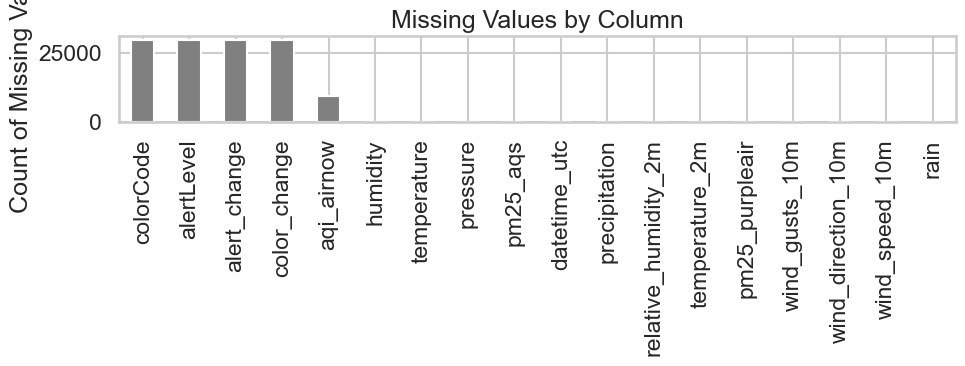

In [63]:
plot_missing_values(df)

At first glance, we can already see gaps — not every system reports at the same times.  
This will matter later, because when we compare measurements, we need overlapping time periods.

### Our first question:  
When we line up the PurpleAir and AQS readings hour by hour, do they match?

If the sensors are accurate, the readings should form a clear diagonal pattern — meaning, when AQS says PM₂.₅ is high, PurpleAir should also say it’s high.

c:\Users\Ailene\Documents\IUS\FA25\THESIS\thesis_project\src\visualizations.py:368: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Ailene\Documents\IUS\FA25\THESIS\thesis_project\src\visualizations.py:368: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Ailene\Documents\IUS\FA25\THESIS\thesis_project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Ailene\Documents\IUS\FA25\THESIS\thesis_project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


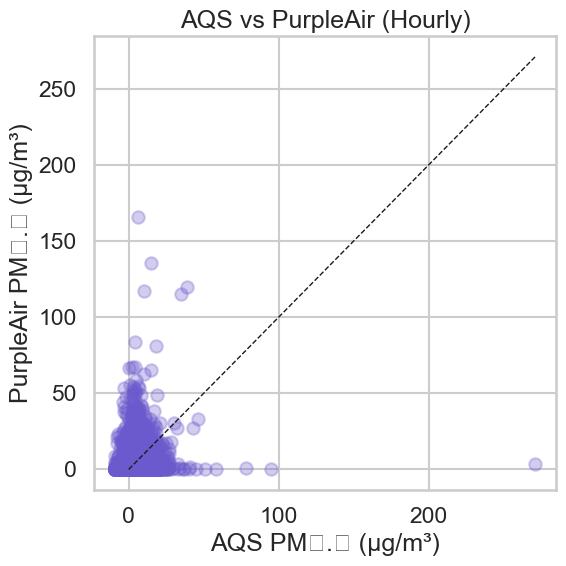

np.float64(0.11921254216273588)

In [65]:
plot_scatter_aqs_vs_purpleair(df)
subset = df.dropna(subset=["pm25_aqs", "pm25_purpleair"])
corr_hourly = subset["pm25_aqs"].corr(subset["pm25_purpleair"])
corr_hourly

The result? A correlation of around **0.12**, which is very weak.

That means that, hour by hour, the two systems often *disagree*.  
Instead of a clear diagonal, we see a cloud of scattered points.  
This raised our first big question:

> “Are the sensors out of sync in time, or are they measuring something different entirely?”

Maybe one system reports slightly earlier or later than the other.  
To check this, we shift the PurpleAir data forward and backward in time, looking at how correlation changes across several hours.

In [ ]:
# Pseudocode placeholder — your lag correlation logic here
# plot_lag_correlation(lags, corrs)

Even after shifting up to ±6 hours, the correlation barely changes.  
So, timing alone doesn’t explain the mismatch.

This tells us something important:
> The differences aren’t about timing — they’re about the sensors themselves and their environment.

If the sensors respond differently depending on weather, that could explain why they disagree.

One strong candidate is **humidity**.  
In Hawaiʻi’s tropical air, water can stick to tiny dust and ash particles, making them bigger — and that can confuse optical sensors like PurpleAir, which detect particle size using light scattering.

In [69]:
plot_bias_vs_humidity(df)

KeyError: ['pm25_aqs', 'pm25_purpleair', 'humidity']

Here we see that as humidity rises, the difference between the two sensors — the *bias* — becomes larger and more unpredictable.

In other words:
- On dry days, the sensors mostly agree.  
- On humid days, PurpleAir tends to **overestimate** PM₂.₅ compared to AQS.

Next, we’ll add another factor: **wind speed**.

In [70]:
plot_bias_by_humidity_and_wind(df)

KeyError: ['pm25_aqs', 'pm25_purpleair', 'humidity', 'wind_speed_10m']

When the air is both **humid and calm**, the sensors disagree the most.  
That makes sense — moisture builds up, and without strong wind, particles hang in the air longer.

We’re beginning to see a story:  
> The disagreement between sensors isn’t random. It’s influenced by weather.

If we zoom out from individual hours and look at *daily averages*, maybe we’ll see that the general trends are still the same.

This is like comparing the shape of the week instead of every single minute of the day.

In [71]:
subset = df.dropna(subset=["pm25_aqs", "pm25_purpleair"])
daily = (
    subset.set_index("datetime_utc")
    .resample("D")[["pm25_aqs", "pm25_purpleair"]]
    .mean()
    .dropna()
)

viz.plot_hourly_vs_daily(subset, daily)
daily_corr = daily["pm25_aqs"].corr(daily["pm25_purpleair"])
daily_corr

KeyError: ['pm25_aqs', 'pm25_purpleair']

At the daily level, the correlation jumps to about **0.4** — a big improvement.  
That means that even though the hourly readings are noisy, the general day-to-day trend is similar.

PurpleAir might not be reliable for precise, hourly monitoring — but it does capture the *bigger picture* of air quality changes.

If weather seems to affect the sensors, maybe we can correct for it using a model.

Let’s try to predict the AQS readings using:
- PurpleAir data, and  
- weather features like humidity, temperature, wind, and rain.

In [ ]:
results = trainer.run_all_models()
results

Despite using several machine learning models (Linear Regression, Random Forest, Gradient Boosting),  
the results all show **R² values near zero** — meaning, the models didn’t learn any reliable pattern.

Even with all the weather data, we can’t accurately predict AQS readings from PurpleAir sensors at the hourly level.

In [ ]:
plot_actual_vs_predicted(y_test, y_pred, title="Predicted vs Actual AQS (Random Forest)")

The green dots here should fall along the diagonal line if predictions matched reality.  
Instead, they’re scattered everywhere — confirming that the data just don’t have a strong enough signal for this kind of model.

### The Data Story So Far

1. **At first glance:** PurpleAir and AQS don’t agree hour by hour.  
2. **After testing:** It’s not a timing issue.  
3. **With weather:** Humidity and calm air make PurpleAir readings less reliable.  
4. **When averaged:** Daily patterns show some alignment.  
5. **With modeling:** Machine learning can’t overcome the noise.  

### What This Means

- Low-cost sensors like PurpleAir are *useful for community awareness*, but not yet reliable enough for regulatory or forecasting use in Hawaiʻi.  
- The tropical humidity and volcanic conditions create unique challenges for these sensors.  
- Understanding those challenges is the first step toward building correction models that *could* make them reliable in the future.

This exploration forms the foundation for the broader **Hawaiʻi Air Quality Forecasting Thesis Project**,  
which aims to improve local air monitoring and forecasting using both regulatory and community data sources.

By the end of this journey, we didn’t just find a weak correlation — we discovered **why** it’s weak, and what that means for real-world air monitoring.

Data science isn’t just about getting high accuracy — it’s about discovering truth through data.  

This project showed that:
- Sometimes models fail because the **data itself tells a more important story**.  
- Even a “failed” model can reveal deep insights about measurement systems, environmental complexity, and the limits of our tools.  

Our next step will be to refine these corrections, test smoothing strategies, and explore long-term trends for forecasting future PM₂.₅ levels in Hawaiʻi.

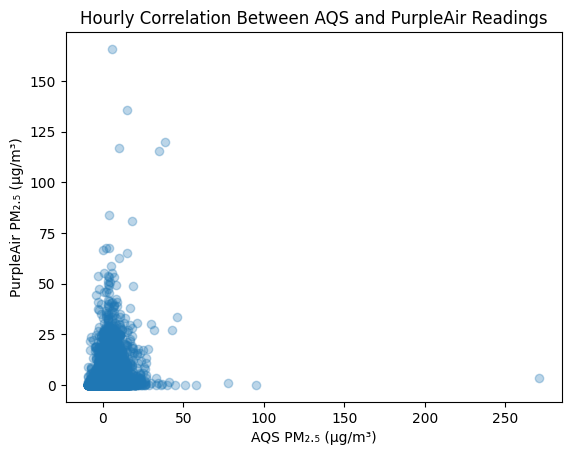

np.float64(0.11921254216273588)

In [54]:
subset = df.dropna(subset=["pm25_aqs", "pm25_purpleair"])
plt.scatter(subset["pm25_aqs"], subset["pm25_purpleair"], alpha=0.3)
plt.xlabel("AQS PM₂.₅ (µg/m³)")
plt.ylabel("PurpleAir PM₂.₅ (µg/m³)")
plt.title("Hourly Correlation Between AQS and PurpleAir Readings")
plt.show()

corr_hourly = subset["pm25_aqs"].corr(subset["pm25_purpleair"])
corr_hourly

### Hourly Correlation

The hourly correlation between PurpleAir and AQS readings is **low (r ≈ 0.12)**.  
At this resolution, there is no clear linear relationship — points are widely scattered, indicating substantial noise and possible timing or calibration issues.

This suggests that short-term PurpleAir data do not reliably track AQS measurements, motivating a closer look at temporal and environmental effects.

In [55]:
daily = (
    subset.set_index("datetime_utc")
    .resample("D")[["pm25_aqs", "pm25_purpleair"]]
    .mean()
    .dropna()
)
daily_corr = daily["pm25_aqs"].corr(daily["pm25_purpleair"])
daily_corr

np.float64(0.40839289396853323)

### Aggregation Reveals Underlying Trends

When aggregated to **daily averages**, the correlation improves significantly (**r ≈ 0.41**).  

This shows that PurpleAir sensors capture the *general daily pattern* of PM₂.₅ variation, even if hourly readings fluctuate too much for direct comparison.  
Temporal smoothing reveals that the signal is real but obscured by short-term variability.

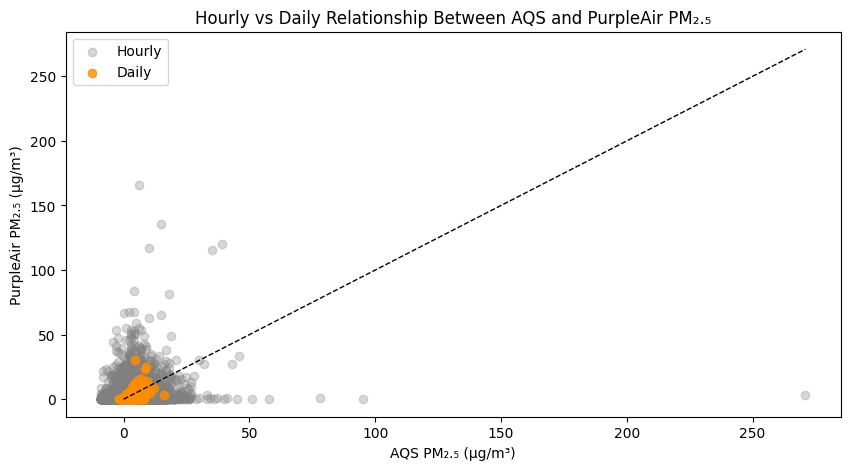

In [56]:
plt.figure(figsize=(10,5))
plt.scatter(subset["pm25_aqs"], subset["pm25_purpleair"], alpha=0.3, label="Hourly", color="gray")
plt.scatter(daily["pm25_aqs"], daily["pm25_purpleair"], alpha=0.8, label="Daily", color="darkorange")
plt.plot([0, max(subset["pm25_aqs"].max(), subset["pm25_purpleair"].max())],
         [0, max(subset["pm25_aqs"].max(), subset["pm25_purpleair"].max())],
         'k--', lw=1)
plt.xlabel("AQS PM₂.₅ (µg/m³)")
plt.ylabel("PurpleAir PM₂.₅ (µg/m³)")
plt.title("Hourly vs Daily Relationship Between AQS and PurpleAir PM₂.₅")
plt.legend()
plt.show()

The hourly points (gray) form a diffuse cloud, while daily means (orange) align more closely along the 1:1 line.  
This confirms that high-frequency PurpleAir data contain noise or temporal misalignment, but general trends are preserved at larger timescales.

## Machine Learning Models

To evaluate whether meteorological features and temporal lags can improve prediction of AQS PM₂.₅,  
we apply multiple models through the `ModelTrainer` class:
- Linear Regression
- Random Forest
- Gradient Boosting
- Published EPA and LRAPA correction formulas

Each model is trained on historical data and evaluated on the most recent 20% of the timeline.

In [57]:
X, y = trainer.prepare_features()
X_train, X_test, y_train, y_test = trainer.train_test_split(X, y)

results = trainer.run_all_models()
results

Feature engineering dropped 26 rows due to lags/rollups.
Train size: 23804, Test size: 5951
Feature engineering dropped 26 rows due to lags/rollups.
Train size: 23804, Test size: 5951
Training model: linear_regression
Saved model: C:\Users\Ailene\Documents\IUS\FA25\THESIS\thesis_project\models\linear_regression.joblib
Evaluation: MAE=2.561, RMSE=3.539, R²=0.095
Training model: random_forest
Saved model: C:\Users\Ailene\Documents\IUS\FA25\THESIS\thesis_project\models\random_forest.joblib
Evaluation: MAE=2.619, RMSE=3.739, R²=-0.011
Tuning GradientBoostingRegressor with TimeSeriesSplit...


KeyboardInterrupt: 

### Model Results Summary

Model performance was consistently low across algorithms, with R² values near or below zero.  
Even advanced ensemble methods could not extract a strong predictive signal, indicating that:
- Short-term variability dominates the sensor readings.
- Meteorological conditions alone cannot correct PurpleAir errors.
- Published correction formulas perform as well as (or better than) machine learning models.

This outcome supports the interpretation that *data quality and environmental factors* — not model complexity — are the limiting factors.

## Conclusions

- Hourly PurpleAir data are unreliable for regulatory use in humid, volcanic conditions.
- Aggregating to daily means reveals moderate agreement (r ≈ 0.4), suggesting that the underlying signal is valid but temporally unstable.
- Model results confirm that predictive skill is limited by input coherence rather than algorithm choice.
- Future work should explore:
  - Sensor calibration transfer functions specific to Hawaiian humidity and sulfate levels.
  - Rolling-window or ensemble smoothing techniques.
  - Network-level anomaly detection to filter erratic sensor behavior.

This analysis demonstrates the value of data-driven diagnostics for understanding when — and how — low-cost sensors can be trusted.

In [10]:
paired.head()

,datetime_utc,pm25_aqs,aqi_airnow,pm25_purpleair,humidity,temperature,pressure,temperature_2m,relative_humidity_2m,precipitation,rain,wind_speed_10m,wind_direction_10m,wind_gusts_10m,alertLevel,colorCode,alert_change,color_change
8760,2022-01-01 10:00:00+00:00,43.0,38.0,27.2,65.0,76.0,963.88,20.676000,89.43752,0.0,0.0,6.877789,137.12111,24.119999,NaN,NaN,NaN,NaN
8761,2022-01-01 11:00:00+00:00,26.0,38.0,0.0,71.0,64.0,884.78,20.226000,90.81337,0.0,0.0,6.608722,150.64235,20.160000,NaN,NaN,NaN,NaN
8762,2022-01-01 12:00:00+00:00,1.0,38.0,0.0,70.0,64.0,884.42,21.176000,89.47540,0.0,0.0,1.835647,168.69011,16.560000,NaN,NaN,NaN,NaN
8763,2022-01-01 13:00:00+00:00,22.0,38.0,3.7,65.0,74.0,962.89,20.376001,91.96430,0.0,0.0,2.036468,224.99990,7.559999,NaN,NaN,NaN,NaN
8765,2022-01-01 15:00:00+00:00,2.0,38.0,1.6,64.0,73.0,962.98,20.726000,81.14661,0.0,0.0,2.595997,213.69010,9.360000,NaN,NaN,NaN,NaN


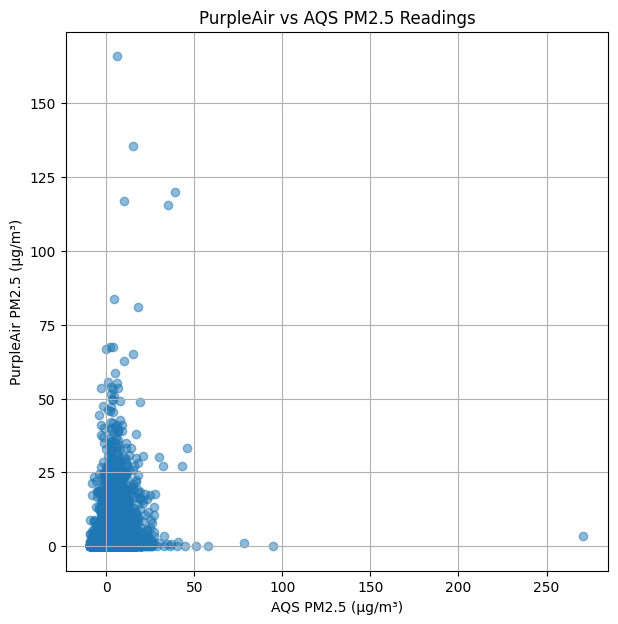

In [7]:
plt.figure(figsize=(7, 7))
plt.scatter(paired["pm25_aqs"], paired["pm25_purpleair"], alpha=0.5)
plt.xlabel("AQS PM2.5 (µg/m³)")
plt.ylabel("PurpleAir PM2.5 (µg/m³)")
plt.title("PurpleAir vs AQS PM2.5 Readings")
plt.grid(True)
plt.show()

In [8]:
corr = paired["pm25_aqs"].corr(paired["pm25_purpleair"])
print(f"Correlation (r): {corr:.3f}")

Correlation (r): 0.119


In [12]:
cols = ["pm25_aqs", "pm25_purpleair", "humidity", "temperature", "pressure"]
subset = df.dropna(subset=cols)

X = subset[["pm25_purpleair", "humidity", "temperature", "pressure"]]
y = subset["pm25_aqs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("Coefficients:", dict(zip(X.columns, model.coef_)))

R²: 0.021154483927807166
Coefficients: {'pm25_purpleair': np.float64(0.12969745407209632), 'humidity': np.float64(-0.02130649406884483), 'temperature': np.float64(0.0027706397004217754), 'pressure': np.float64(-0.0022566538115013253)}


C:\Users\Ailene\AppData\Local\Temp\ipykernel_9756\1713766816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["pm25_corrected"] = model.predict(X)


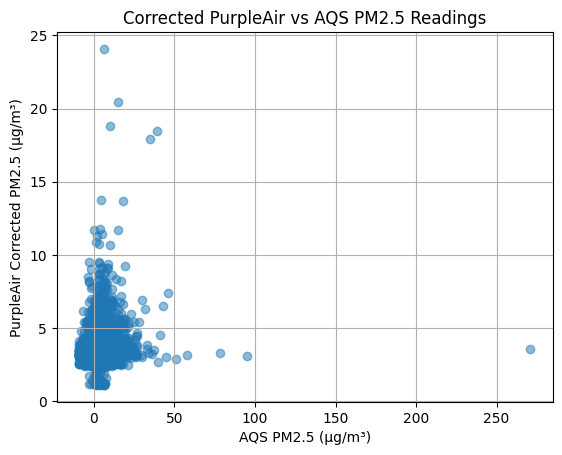

Correlation after correction: 0.14011222902686246


In [13]:
subset["pm25_corrected"] = model.predict(X)

plt.scatter(subset["pm25_aqs"], subset["pm25_corrected"], alpha=0.5)
plt.xlabel("AQS PM2.5 (µg/m³)")
plt.ylabel("PurpleAir Corrected PM2.5 (µg/m³)")
plt.title("Corrected PurpleAir vs AQS PM2.5 Readings")
plt.grid(True)
plt.show()

print("Correlation after correction:", subset["pm25_aqs"].corr(subset["pm25_corrected"]))

In [15]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
print("R² test:", model.score(X_test, y_test))

R² test: -0.09878527986989671


In [17]:
lags = np.arange(-6, 7)  # test from -6 to +6 hours
corrs = []

for lag in lags:
    shifted = paired["pm25_purpleair"].shift(lag)
    r = paired["pm25_aqs"].corr(shifted)
    corrs.append(r)
    print(f"Lag {lag:+d} hours → r = {r:.3f}")

Lag -6 hours → r = 0.081
Lag -5 hours → r = 0.080
Lag -4 hours → r = 0.086
Lag -3 hours → r = 0.090
Lag -2 hours → r = 0.101
Lag -1 hours → r = 0.098
Lag +0 hours → r = 0.119
Lag +1 hours → r = 0.122
Lag +2 hours → r = 0.101
Lag +3 hours → r = 0.095
Lag +4 hours → r = 0.123
Lag +5 hours → r = 0.090
Lag +6 hours → r = 0.087


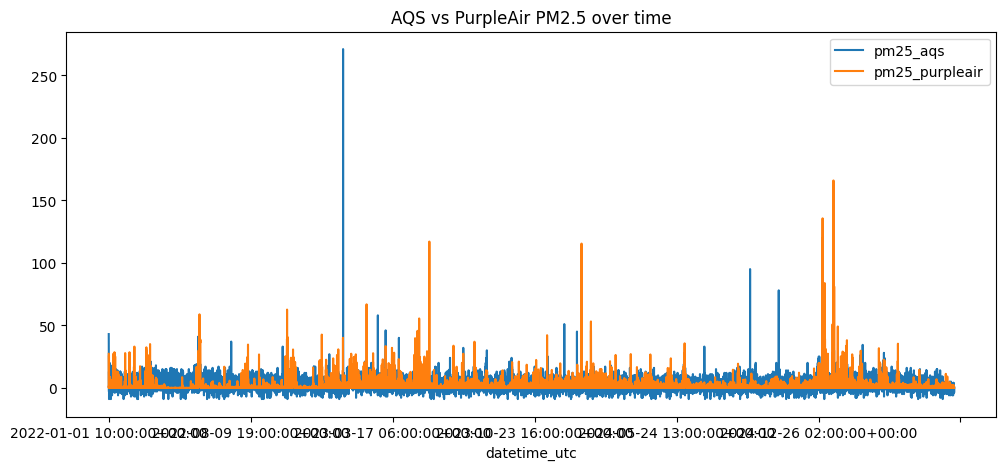

In [18]:
paired[["datetime_utc","pm25_aqs","pm25_purpleair"]].set_index("datetime_utc").plot(figsize=(12,5))
plt.title("AQS vs PurpleAir PM2.5 over time")
plt.show()

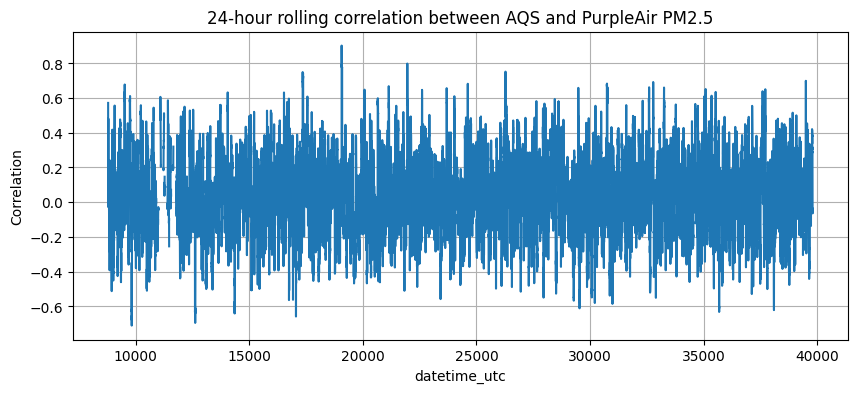

In [19]:
rolling_corr = paired["pm25_aqs"].rolling(24).corr(paired["pm25_purpleair"])
rolling_corr.plot(figsize=(10,4))
plt.title("24-hour rolling correlation between AQS and PurpleAir PM2.5")
plt.xlabel("datetime_utc")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()


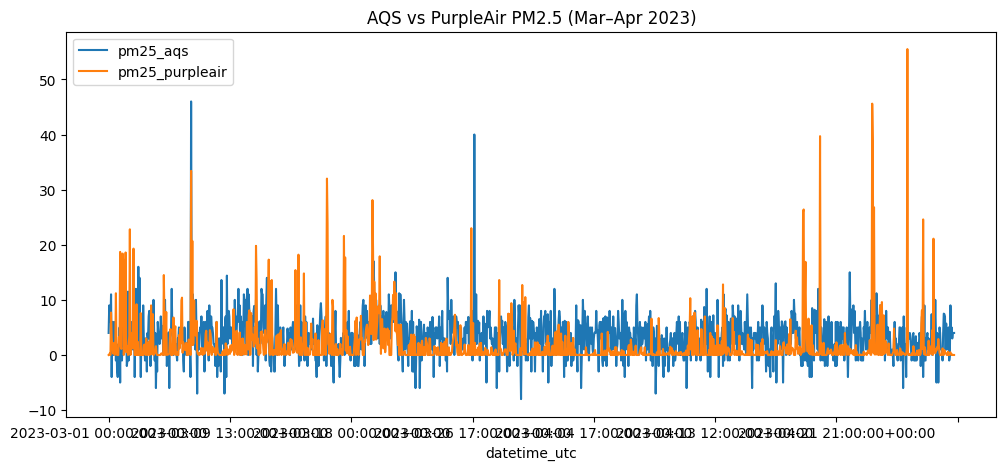

In [20]:
subset = paired[(paired["datetime_utc"] >= "2023-03-01") & 
                (paired["datetime_utc"] <= "2023-04-30")]
subset.set_index("datetime_utc")[["pm25_aqs", "pm25_purpleair"]].plot(figsize=(12,5))
plt.title("AQS vs PurpleAir PM2.5 (Mar–Apr 2023)")
plt.show()

In [22]:
cols = [
    "pm25_aqs", "pm25_purpleair",
    "humidity", "temperature", "pressure",
    "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m"
]

subset = df.dropna(subset=cols)

X = subset[[
    "pm25_purpleair",
    "humidity", "temperature", "pressure",
    "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m"
]]
y = subset["pm25_aqs"]

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

print("R²:", r2_score(y, y_pred))
print("Coefficients:")
for var, coef in zip(X.columns, model.coef_):
    print(f"  {var:20s} {coef:.4f}")

R²: 0.023534907527725135
Coefficients:
  pm25_purpleair       0.1295
  humidity             -0.0172
  temperature          0.0020
  pressure             -0.0018
  wind_speed_10m       0.0027
  wind_direction_10m   -0.0016
  wind_gusts_10m       0.0172


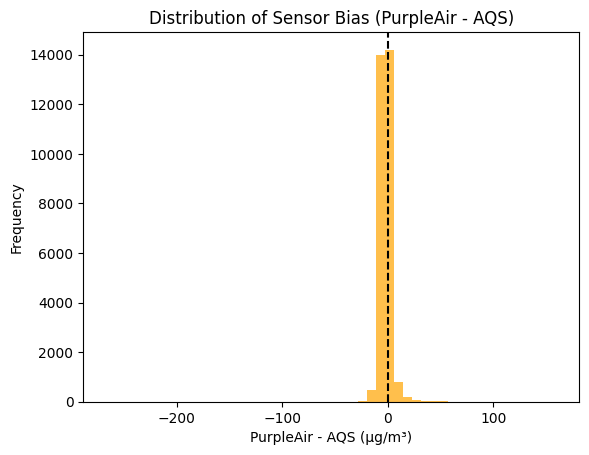

In [25]:
paired = df.dropna(subset=["pm25_aqs", "pm25_purpleair"]).copy()
paired.loc[:, "bias"] = paired["pm25_purpleair"] - paired["pm25_aqs"]

plt.hist(paired["bias"], bins=50, color="orange", alpha=0.7)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("PurpleAir - AQS (µg/m³)")
plt.ylabel("Frequency")
plt.title("Distribution of Sensor Bias (PurpleAir - AQS)")
plt.show()

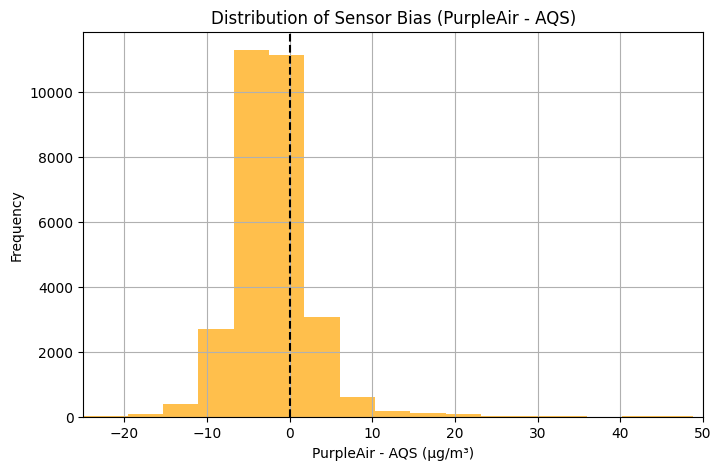

Mean bias: -2.0775259393573084
Median bias: -2.3000000000000003


In [26]:
plt.figure(figsize=(8,5))
plt.hist(paired["bias"], bins=100, color="orange", alpha=0.7)
plt.xlim(-25, 50)  # focus on reasonable range
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("PurpleAir - AQS (µg/m³)")
plt.ylabel("Frequency")
plt.title("Distribution of Sensor Bias (PurpleAir - AQS)")
plt.grid(True)
plt.show()

print("Mean bias:", paired["bias"].mean())
print("Median bias:", paired["bias"].median())

C:\Users\Ailene\AppData\Local\Temp\ipykernel_9756\3545817183.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bias_stats = paired.groupby("humidity_bin")["bias"].agg(["mean", "std"])


<Axes: title={'center': 'Variability of Sensor Bias by Humidity'}, xlabel='humidity_bin'>

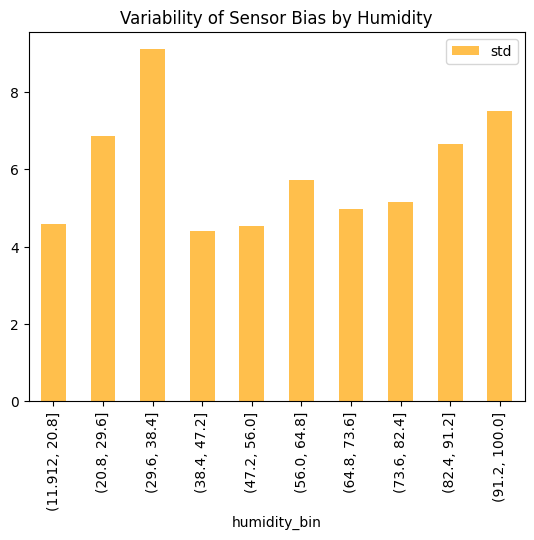

In [28]:
paired["humidity_bin"] = pd.cut(paired["humidity"], bins=10)
bias_stats = paired.groupby("humidity_bin")["bias"].agg(["mean", "std"])

bias_stats.plot(
    y="std",
    kind="bar",
    color="orange",
    alpha=0.7,
    title="Variability of Sensor Bias by Humidity"
)

C:\Users\Ailene\AppData\Local\Temp\ipykernel_9756\72784246.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_stats = paired.groupby("wind_bin")["bias"].agg(["mean", "std"])


<Axes: title={'center': 'Variability of Sensor Bias by Wind Speed'}, xlabel='wind_bin'>

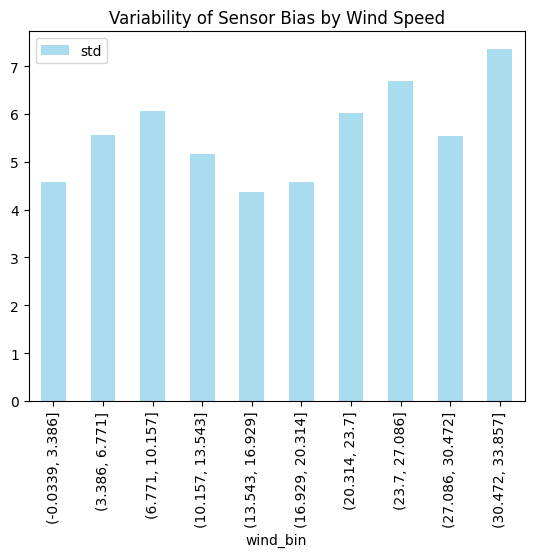

In [29]:
paired["wind_bin"] = pd.cut(paired["wind_speed_10m"], bins=10)
wind_stats = paired.groupby("wind_bin")["bias"].agg(["mean", "std"])

wind_stats.plot(
    y="std", kind="bar", color="skyblue", alpha=0.7,
    title="Variability of Sensor Bias by Wind Speed"
)

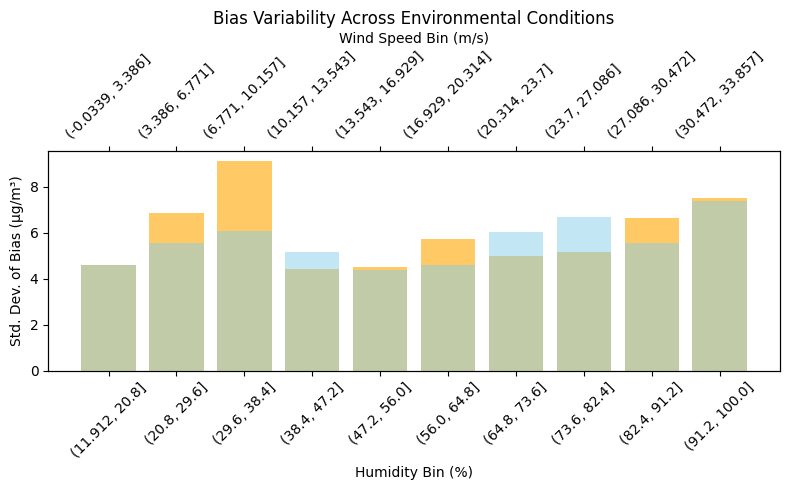

In [32]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Primary axis (humidity)
ax1.bar(bias_stats.index.astype(str), bias_stats["std"], color="orange", alpha=0.6, label="Humidity")
ax1.set_xlabel("Humidity Bin (%)")
ax1.set_ylabel("Std. Dev. of Bias (µg/m³)")
ax1.tick_params(axis='x', rotation=45)

# Secondary axis (wind speed)
ax2 = ax1.twiny()
ax2.bar(wind_stats.index.astype(str), wind_stats["std"], color="skyblue", alpha=0.5, label="Wind Speed")
ax2.set_xlabel("Wind Speed Bin (m/s)")
ax2.tick_params(axis='x', rotation=45)

plt.title("Bias Variability Across Environmental Conditions")
plt.tight_layout()
plt.show()

R² raw:        -1.081
R² corrected:  -0.974
MAE raw:       3.66
MAE corrected: 3.3


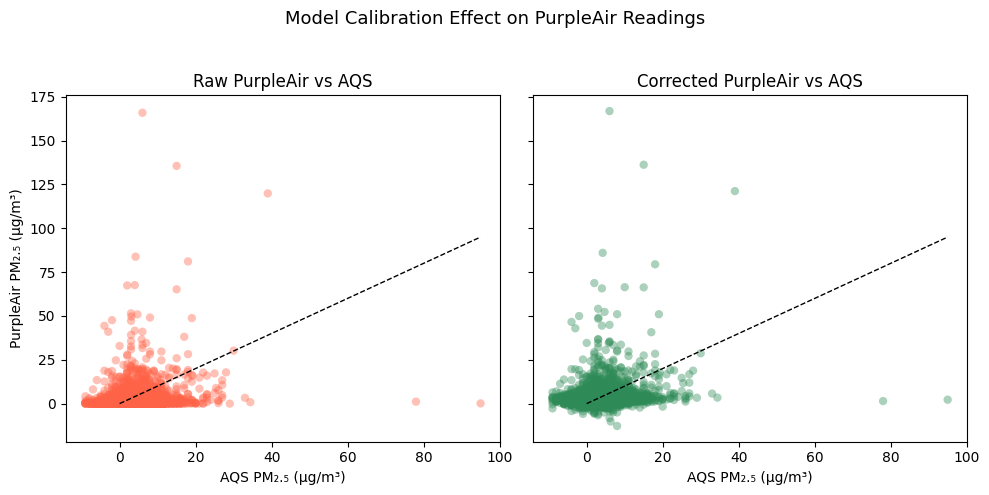

In [37]:
# Prepare data
cols = ["pm25_aqs","pm25_purpleair","humidity","temperature","pressure",
        "wind_speed_10m","wind_direction_10m","wind_gusts_10m"]
data = df.dropna(subset=cols).copy()
data["delta"] = data["pm25_aqs"] - data["pm25_purpleair"]

X = data[["humidity","temperature","pressure","wind_speed_10m",
           "wind_direction_10m","wind_gusts_10m"]]
y = data["delta"]
pa = data["pm25_purpleair"]
aqs = data["pm25_aqs"]

# Split (no shuffle because this is time series)
X_train, X_test, y_train, y_test, pa_train, pa_test, aqs_train, aqs_test = train_test_split(
    X, y, pa, aqs, test_size=0.3, shuffle=False
)

# Train random forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# Predict residual (delta) and correct PurpleAir
delta_hat = rf.predict(X_test)
pa_corr = pa_test + delta_hat

# Evaluate improvement
print("R² raw:       ", round(r2_score(aqs_test, pa_test), 3))
print("R² corrected: ", round(r2_score(aqs_test, pa_corr), 3))
print("MAE raw:      ", round(mean_absolute_error(aqs_test, pa_test), 2))
print("MAE corrected:", round(mean_absolute_error(aqs_test, pa_corr), 2))

# Scatterplots
fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True, sharey=True)

axes[0].scatter(aqs_test, pa_test, alpha=0.4, color="tomato", edgecolor="none")
axes[0].plot([0, max(aqs_test)], [0, max(aqs_test)], 'k--', lw=1)
axes[0].set_title("Raw PurpleAir vs AQS")
axes[0].set_xlabel("AQS PM₂.₅ (µg/m³)")
axes[0].set_ylabel("PurpleAir PM₂.₅ (µg/m³)")

axes[1].scatter(aqs_test, pa_corr, alpha=0.4, color="seagreen", edgecolor="none")
axes[1].plot([0, max(aqs_test)], [0, max(aqs_test)], 'k--', lw=1)
axes[1].set_title("Corrected PurpleAir vs AQS")
axes[1].set_xlabel("AQS PM₂.₅ (µg/m³)")

plt.suptitle("Model Calibration Effect on PurpleAir Readings", fontsize=13)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


C:\Users\Ailene\AppData\Local\Temp\ipykernel_9756\456757429.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bias_table = paired.groupby(["hum_bin","wind_bin"])["bias"].mean().reset_index()


R² raw:        -0.899
R² corrected:  -0.65
MAE raw:       3.82
MAE corrected: 3.21


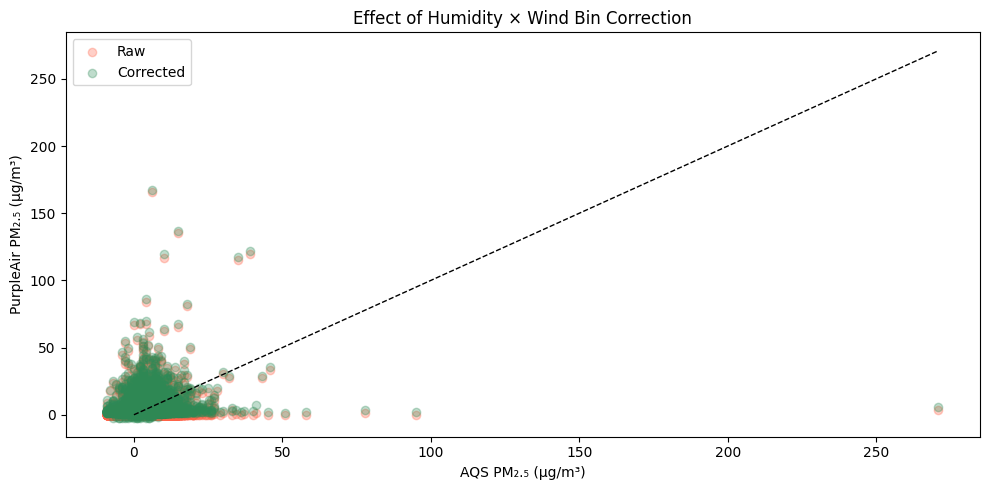

In [39]:
# 1. Prepare data
paired = df.dropna(subset=["pm25_aqs","pm25_purpleair","humidity","wind_speed_10m"]).copy()
paired["bias"] = paired["pm25_purpleair"] - paired["pm25_aqs"]

# 2. Create bins for humidity and wind
paired["hum_bin"]  = pd.cut(paired["humidity"], bins=8)
paired["wind_bin"] = pd.cut(paired["wind_speed_10m"], bins=8)

# 3. Compute average bias per (humidity, wind) bin combo
bias_table = paired.groupby(["hum_bin","wind_bin"])["bias"].mean().reset_index()

# 4. Merge back to assign each row its corresponding mean bias
paired = paired.merge(bias_table, on=["hum_bin","wind_bin"], how="left", suffixes=("", "_mean"))

# 5. Apply correction
paired["pa_corrected"] = paired["pm25_purpleair"] - paired["bias_mean"]

# 6. Evaluate improvement
print("R² raw:       ", round(r2_score(paired["pm25_aqs"], paired["pm25_purpleair"]), 3))
print("R² corrected: ", round(r2_score(paired["pm25_aqs"], paired["pa_corrected"]), 3))
print("MAE raw:      ", round(mean_absolute_error(paired["pm25_aqs"], paired["pm25_purpleair"]), 2))
print("MAE corrected:", round(mean_absolute_error(paired["pm25_aqs"], paired["pa_corrected"]), 2))

# 7. Visualize before/after
plt.figure(figsize=(10,5))
plt.scatter(paired["pm25_aqs"], paired["pm25_purpleair"], alpha=0.3, label="Raw", color="tomato")
plt.scatter(paired["pm25_aqs"], paired["pa_corrected"], alpha=0.3, label="Corrected", color="seagreen")
plt.plot([0, paired["pm25_aqs"].max()], [0, paired["pm25_aqs"].max()], 'k--', lw=1)
plt.xlabel("AQS PM₂.₅ (µg/m³)")
plt.ylabel("PurpleAir PM₂.₅ (µg/m³)")
plt.title("Effect of Humidity × Wind Bin Correction")
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Error Magnitude vs. Humidity')

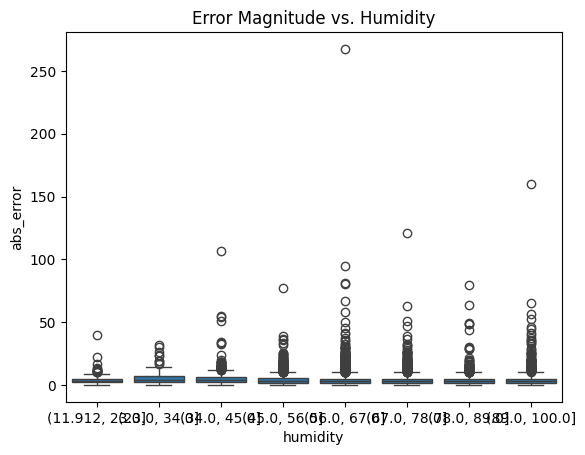

In [42]:
paired["abs_error"] = abs(paired["pm25_purpleair"] - paired["pm25_aqs"])
sns.boxplot(x=pd.cut(paired["humidity"], bins=8), y="abs_error", data=paired)
plt.title("Error Magnitude vs. Humidity")

In [43]:
stable = df.dropna(subset=["pm25_aqs","pm25_purpleair","humidity","wind_speed_10m"]).copy()

# Apply filtering thresholds
stable = stable[(stable["humidity"] < 80) & (stable["wind_speed_10m"] < 20)]

print(f"Filtered dataset size: {len(stable)} rows (out of {len(df)})")

# Evaluate correlation and error
r2_raw = r2_score(stable["pm25_aqs"], stable["pm25_purpleair"])
mae_raw = mean_absolute_error(stable["pm25_aqs"], stable["pm25_purpleair"])
corr = stable["pm25_aqs"].corr(stable["pm25_purpleair"])

print(f"Correlation (r): {corr:.3f}")
print(f"R²: {r2_raw:.3f}")
print(f"MAE: {mae_raw:.2f}")

Filtered dataset size: 22759 rows (out of 41927)
Correlation (r): 0.139
R²: -0.718
MAE: 3.77


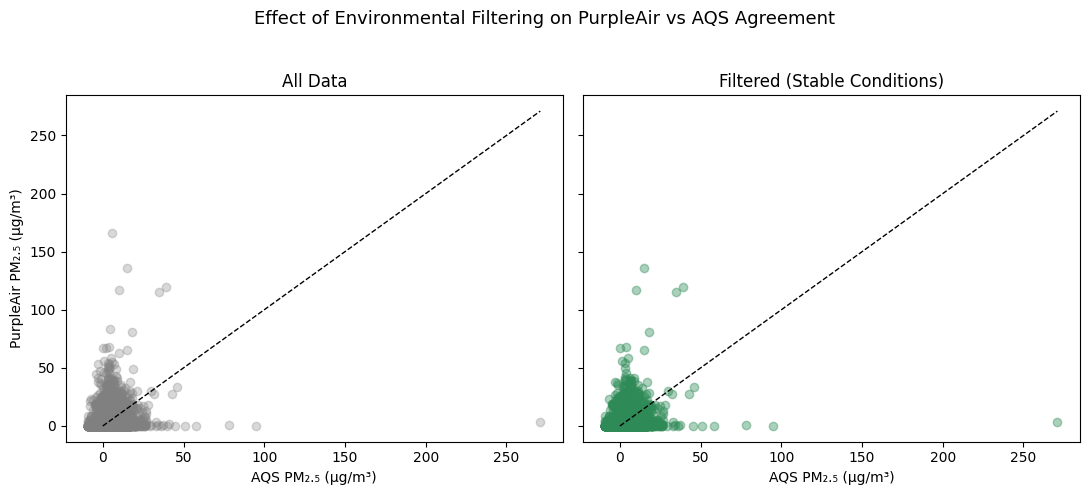

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11,5), sharex=True, sharey=True)

# Unfiltered
plt.subplot(1, 2, 1)
plt.scatter(df["pm25_aqs"], df["pm25_purpleair"], alpha=0.3, color="gray", label="All data")
plt.plot([0, df["pm25_aqs"].max()], [0, df["pm25_aqs"].max()], 'k--', lw=1)
plt.title("All Data")
plt.xlabel("AQS PM₂.₅ (µg/m³)")
plt.ylabel("PurpleAir PM₂.₅ (µg/m³)")

# Filtered
plt.subplot(1, 2, 2)
plt.scatter(stable["pm25_aqs"], stable["pm25_purpleair"], alpha=0.4, color="seagreen", label="Filtered (<80% RH, <20 m/s)")
plt.plot([0, stable["pm25_aqs"].max()], [0, stable["pm25_aqs"].max()], 'k--', lw=1)
plt.title("Filtered (Stable Conditions)")
plt.xlabel("AQS PM₂.₅ (µg/m³)")

plt.suptitle("Effect of Environmental Filtering on PurpleAir vs AQS Agreement", fontsize=13)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


<Axes: >

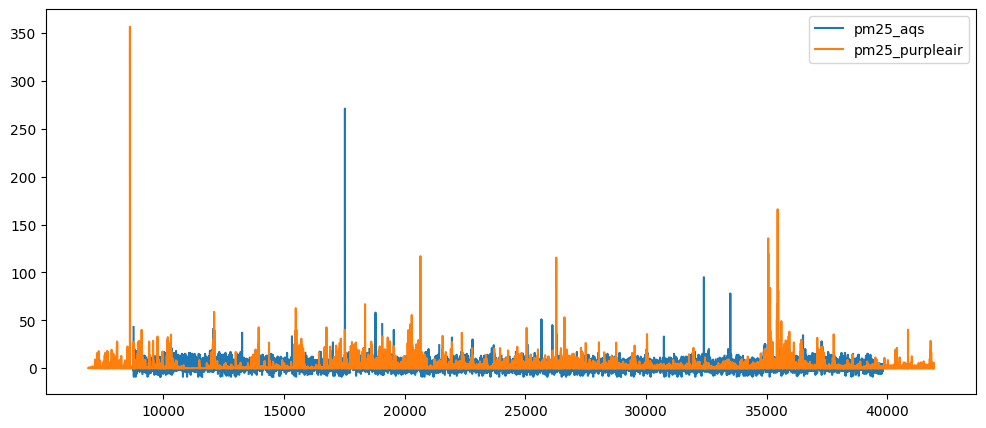

In [45]:
df[["pm25_aqs", "pm25_purpleair"]].plot(figsize=(12,5))

In [47]:
subset = df.dropna(subset=["pm25_purpleair", "pm25_aqs"]).copy()

# Define features and target
X = np.c_[subset["pm25_purpleair"], subset["pm25_purpleair"]**2]
y = subset["pm25_aqs"]

# Fit quadratic regression
model = LinearRegression().fit(X, y)
r2 = model.score(X, y)
coef = model.coef_
intercept = model.intercept_

print(f"R²: {r2:.3f}")
print(f"Model: AQS ≈ {intercept:.3f} + {coef[0]:.3f}·PA + {coef[1]:.5f}·PA²")

R²: 0.015
Model: AQS ≈ 3.112 + 0.156·PA + -0.00065·PA²


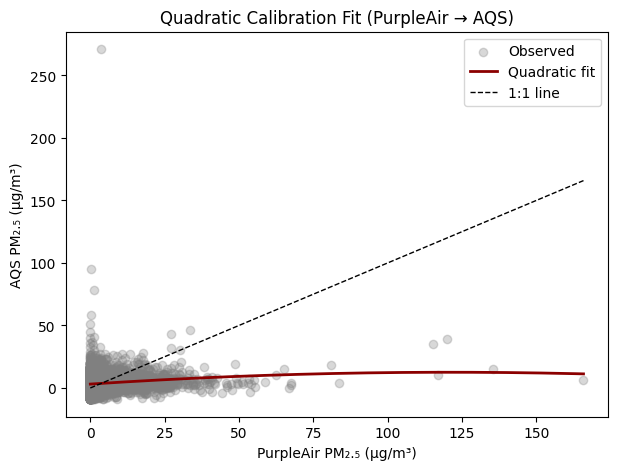

In [48]:
x_line = np.linspace(0, subset["pm25_purpleair"].max(), 200)
y_line = model.predict(np.c_[x_line, x_line**2])

plt.figure(figsize=(7,5))
plt.scatter(subset["pm25_purpleair"], subset["pm25_aqs"], alpha=0.3, color="gray", label="Observed")
plt.plot(x_line, y_line, color="darkred", lw=2, label="Quadratic fit")
plt.plot(x_line, x_line, 'k--', lw=1, label="1:1 line")
plt.xlabel("PurpleAir PM₂.₅ (µg/m³)")
plt.ylabel("AQS PM₂.₅ (µg/m³)")
plt.title("Quadratic Calibration Fit (PurpleAir → AQS)")
plt.legend()
plt.show()

In [50]:
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"], errors="coerce")

# Drop rows where the datetime couldn’t be parsed
df = df.dropna(subset=["datetime_utc"])

# Resample to daily mean values
daily = (
    df.set_index("datetime_utc")
      .resample("D")[["pm25_aqs", "pm25_purpleair"]]
      .mean()
      .dropna()
)

# Compute and print correlation
corr = daily["pm25_aqs"].corr(daily["pm25_purpleair"])
print(f"Daily correlation: {corr:.3f}")

Daily correlation: 0.407


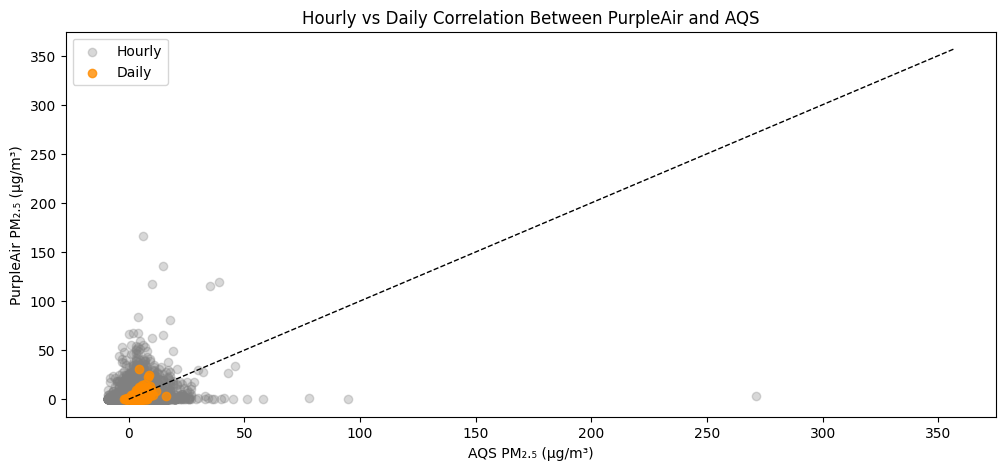

In [51]:
plt.figure(figsize=(12,5))
plt.scatter(df["pm25_aqs"], df["pm25_purpleair"], alpha=0.3, label="Hourly", color="gray")
plt.scatter(daily["pm25_aqs"], daily["pm25_purpleair"], alpha=0.8, label="Daily", color="darkorange")
plt.plot([0, max(df["pm25_aqs"].max(), df["pm25_purpleair"].max())],
         [0, max(df["pm25_aqs"].max(), df["pm25_purpleair"].max())],
         'k--', lw=1)
plt.xlabel("AQS PM₂.₅ (µg/m³)")
plt.ylabel("PurpleAir PM₂.₅ (µg/m³)")
plt.title("Hourly vs Daily Correlation Between PurpleAir and AQS")
plt.legend()
plt.show()
